In [2]:
import pandas as pd
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
features_path = os.path.join(project_root, "data", "processed", "features.csv")

df_model = pd.read_csv(features_path)
print(df_model.shape)

(125973, 123)


In [3]:
print(df_model["binary_label"].unique())
print(df_model["binary_label"].value_counts())

[1 0]
binary_label
1    67343
0    58630
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["binary_label"])
y = df_model["binary_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1 Score": f1_score(y_test, y_pred, pos_label=1),
        "Train Time (s)": round(train_time, 2)
    })
    print(f"{name} done in {train_time:.2f}s")

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df

Random Forest done in 1.96s
Decision Tree done in 1.43s


C:\Users\gowth\Music\ids-ml-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression done in 29.76s
K-Nearest Neighbors done in 0.20s


,Model,Accuracy,Precision,Recall,F1 Score,Train Time (s)
0,Random Forest,0.999127,0.998813,0.999555,0.999184,1.96
1,Decision Tree,0.998055,0.998588,0.997773,0.998180,1.43
3,K-Nearest Neighbors,0.996587,0.997620,0.995991,0.996805,0.20
2,Logistic Regression,0.953880,0.957407,0.956270,0.956838,29.76


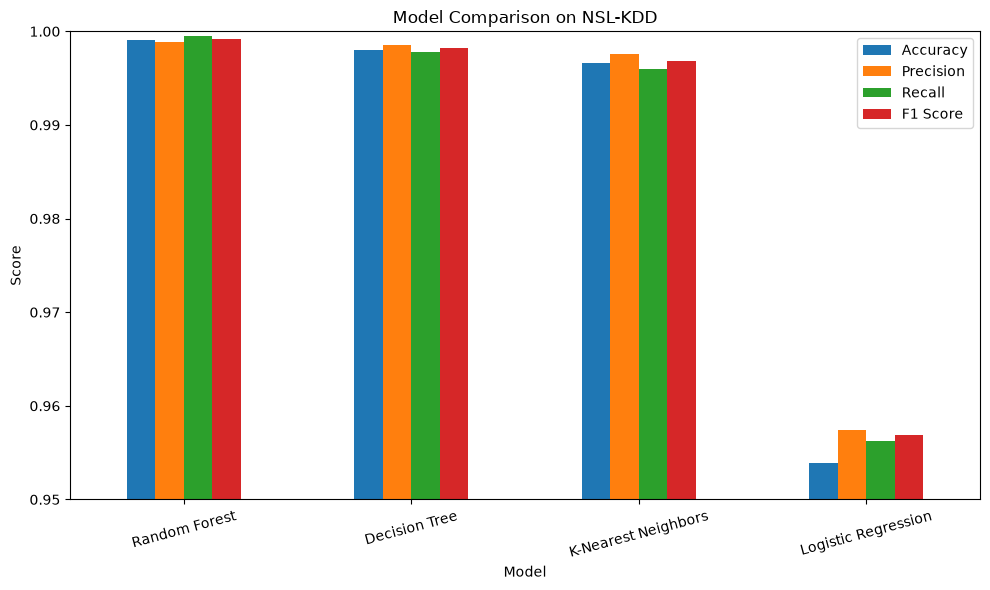

In [6]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(10, 6), ylim=(0.95, 1.0)
)
plt.title("Model Comparison on NSL-KDD")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

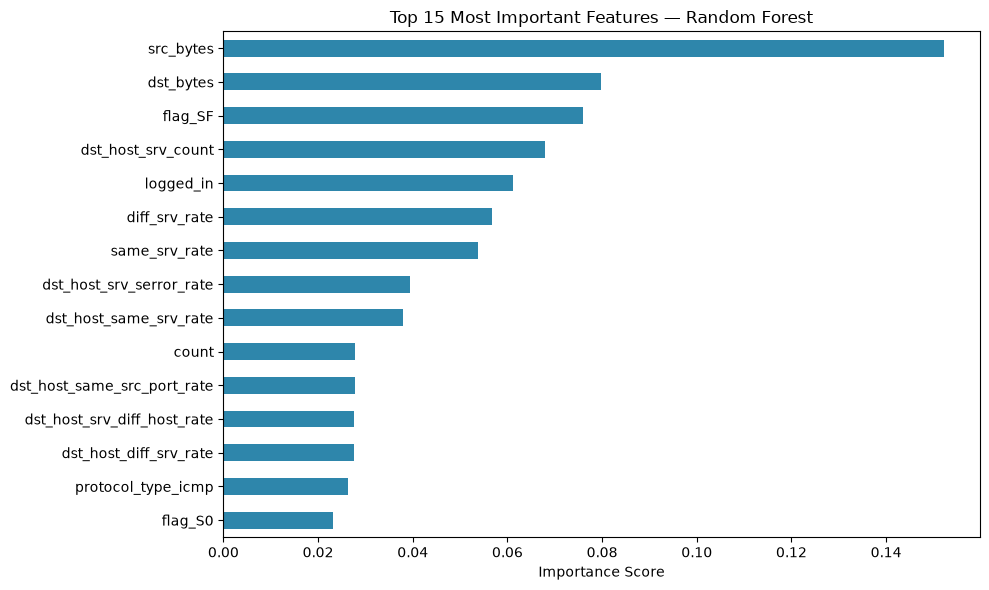

src_bytes                      0.152219
dst_bytes                      0.079726
flag_SF                        0.076018
dst_host_srv_count             0.067899
logged_in                      0.061179
diff_srv_rate                  0.056805
same_srv_rate                  0.053723
dst_host_srv_serror_rate       0.039331
dst_host_same_srv_rate         0.037851
count                          0.027846
dst_host_same_src_port_rate    0.027725
dst_host_srv_diff_host_rate    0.027688
dst_host_diff_srv_rate         0.027594
protocol_type_icmp             0.026268
flag_S0                        0.023249
dtype: float64


In [7]:
import matplotlib.pyplot as plt

# Re-fit Random Forest alone if not already in memory as 'model'
rf = models["Random Forest"]

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh", color="#2E86AB")
plt.title("Top 15 Most Important Features — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(top_features)

In [8]:
import pandas as pd

rf = models["Random Forest"]

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(20)

print(top_features)

src_bytes                      0.152219
dst_bytes                      0.079726
flag_SF                        0.076018
dst_host_srv_count             0.067899
logged_in                      0.061179
diff_srv_rate                  0.056805
same_srv_rate                  0.053723
dst_host_srv_serror_rate       0.039331
dst_host_same_srv_rate         0.037851
count                          0.027846
dst_host_same_src_port_rate    0.027725
dst_host_srv_diff_host_rate    0.027688
dst_host_diff_srv_rate         0.027594
protocol_type_icmp             0.026268
flag_S0                        0.023249
dst_host_count                 0.019352
service_http                   0.019287
service_private                0.016946
dst_host_serror_rate           0.016063
dst_host_rerror_rate           0.013331
dtype: float64
